# SHAP Analysis for CCMA CRISPR Transfer Model

This notebook summarizes SHAP outputs generated by `python -m PhenPred.vae.RunCCMAShap`.
It focuses on global and target-level interpretation for CRISPR explanations.

When mutations are used as conditionals, those SHAP features appear as `conditionals_mut_*`.
This notebook relabels them as `mutation_conditionals` for plotting.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

proj_dir = "/home/ubuntu/scai/PhenPred"
sys.path.extend([proj_dir])
import PhenPred


In [2]:
# Set this to your SHAP run timestamp
# TIMESTAMP = "20260225_133435"
# TIMESTAMP = "20260225_223235"
# TIMESTAMP = "20260226_024535"
TIMESTAMP = "20260226_031500"

ROOT = Path.cwd()
if not (ROOT / "reports").exists() and (ROOT.parent / "reports").exists():
    ROOT = ROOT.parent

FILES_DIR = ROOT / "reports" / "vae" / "files"
OUT_DIR = ROOT / "reports" / "vae" / "shap_ccma"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_RANK_CSV = FILES_DIR / f"{TIMESTAMP}_shap_feature_ranking_crisprcas9.csv"
OMIC_RANK_CSV = FILES_DIR / f"{TIMESTAMP}_shap_omic_ranking_crisprcas9.csv"
TOP_FEATURES_FEATHER = FILES_DIR / f"{TIMESTAMP}_shap_values_top_features_crisprcas9.feather"
FULL_SHAP_CSV = FILES_DIR / f"{TIMESTAMP}_shap_values_crisprcas9.csv.gz"

print("FEATURE_RANK_CSV:", FEATURE_RANK_CSV)
print("OMIC_RANK_CSV:", OMIC_RANK_CSV)
print("TOP_FEATURES_FEATHER:", TOP_FEATURES_FEATHER)
print("FULL_SHAP_CSV:", FULL_SHAP_CSV)



FEATURE_RANK_CSV: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_feature_ranking_crisprcas9.csv
OMIC_RANK_CSV: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_omic_ranking_crisprcas9.csv
TOP_FEATURES_FEATHER: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_values_top_features_crisprcas9.feather
FULL_SHAP_CSV: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_values_crisprcas9.csv.gz


In [3]:
feature_rank_df = pd.read_csv(FEATURE_RANK_CSV)
omic_rank_df = pd.read_csv(OMIC_RANK_CSV)

display(feature_rank_df.head())
display(omic_rank_df)

print("n_features ranked:", len(feature_rank_df))
print("n_omics ranked:", len(omic_rank_df))

,feature,importance,omic_layer
0,conditionals_mut_TP53,0.001612,conditionals
1,transcriptomics_RADX,0.001317,transcriptomics
2,methylation_CMTM7,0.001292,methylation
3,methylation_PRDX1,0.001225,methylation
4,transcriptomics_COL25A1,0.001203,transcriptomics


,omic_layer,importance
0,transcriptomics,0.000293
1,methylation,0.000254
2,conditionals,0.000018


n_features ranked: 11724
n_omics ranked: 3


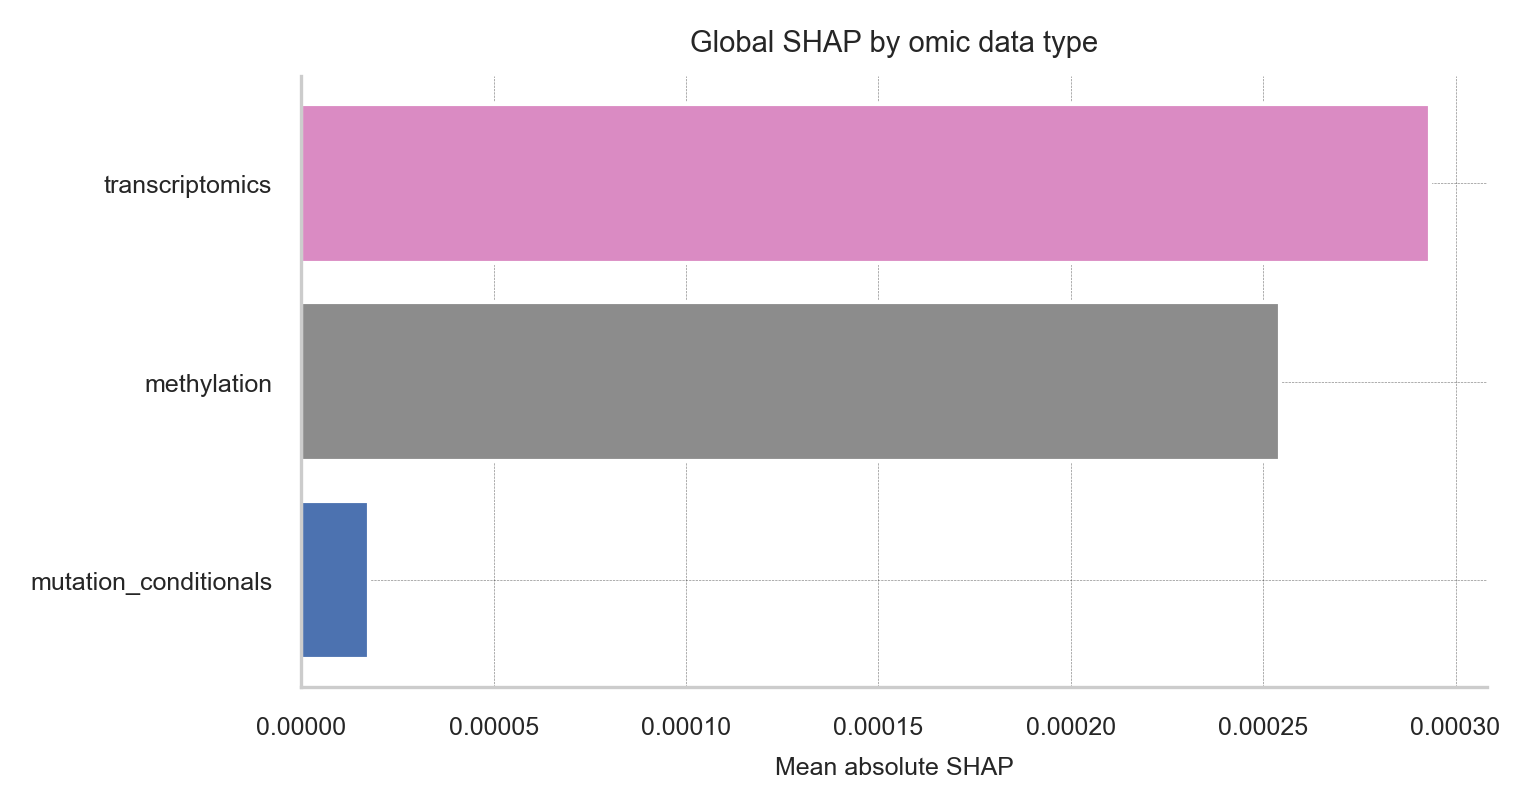

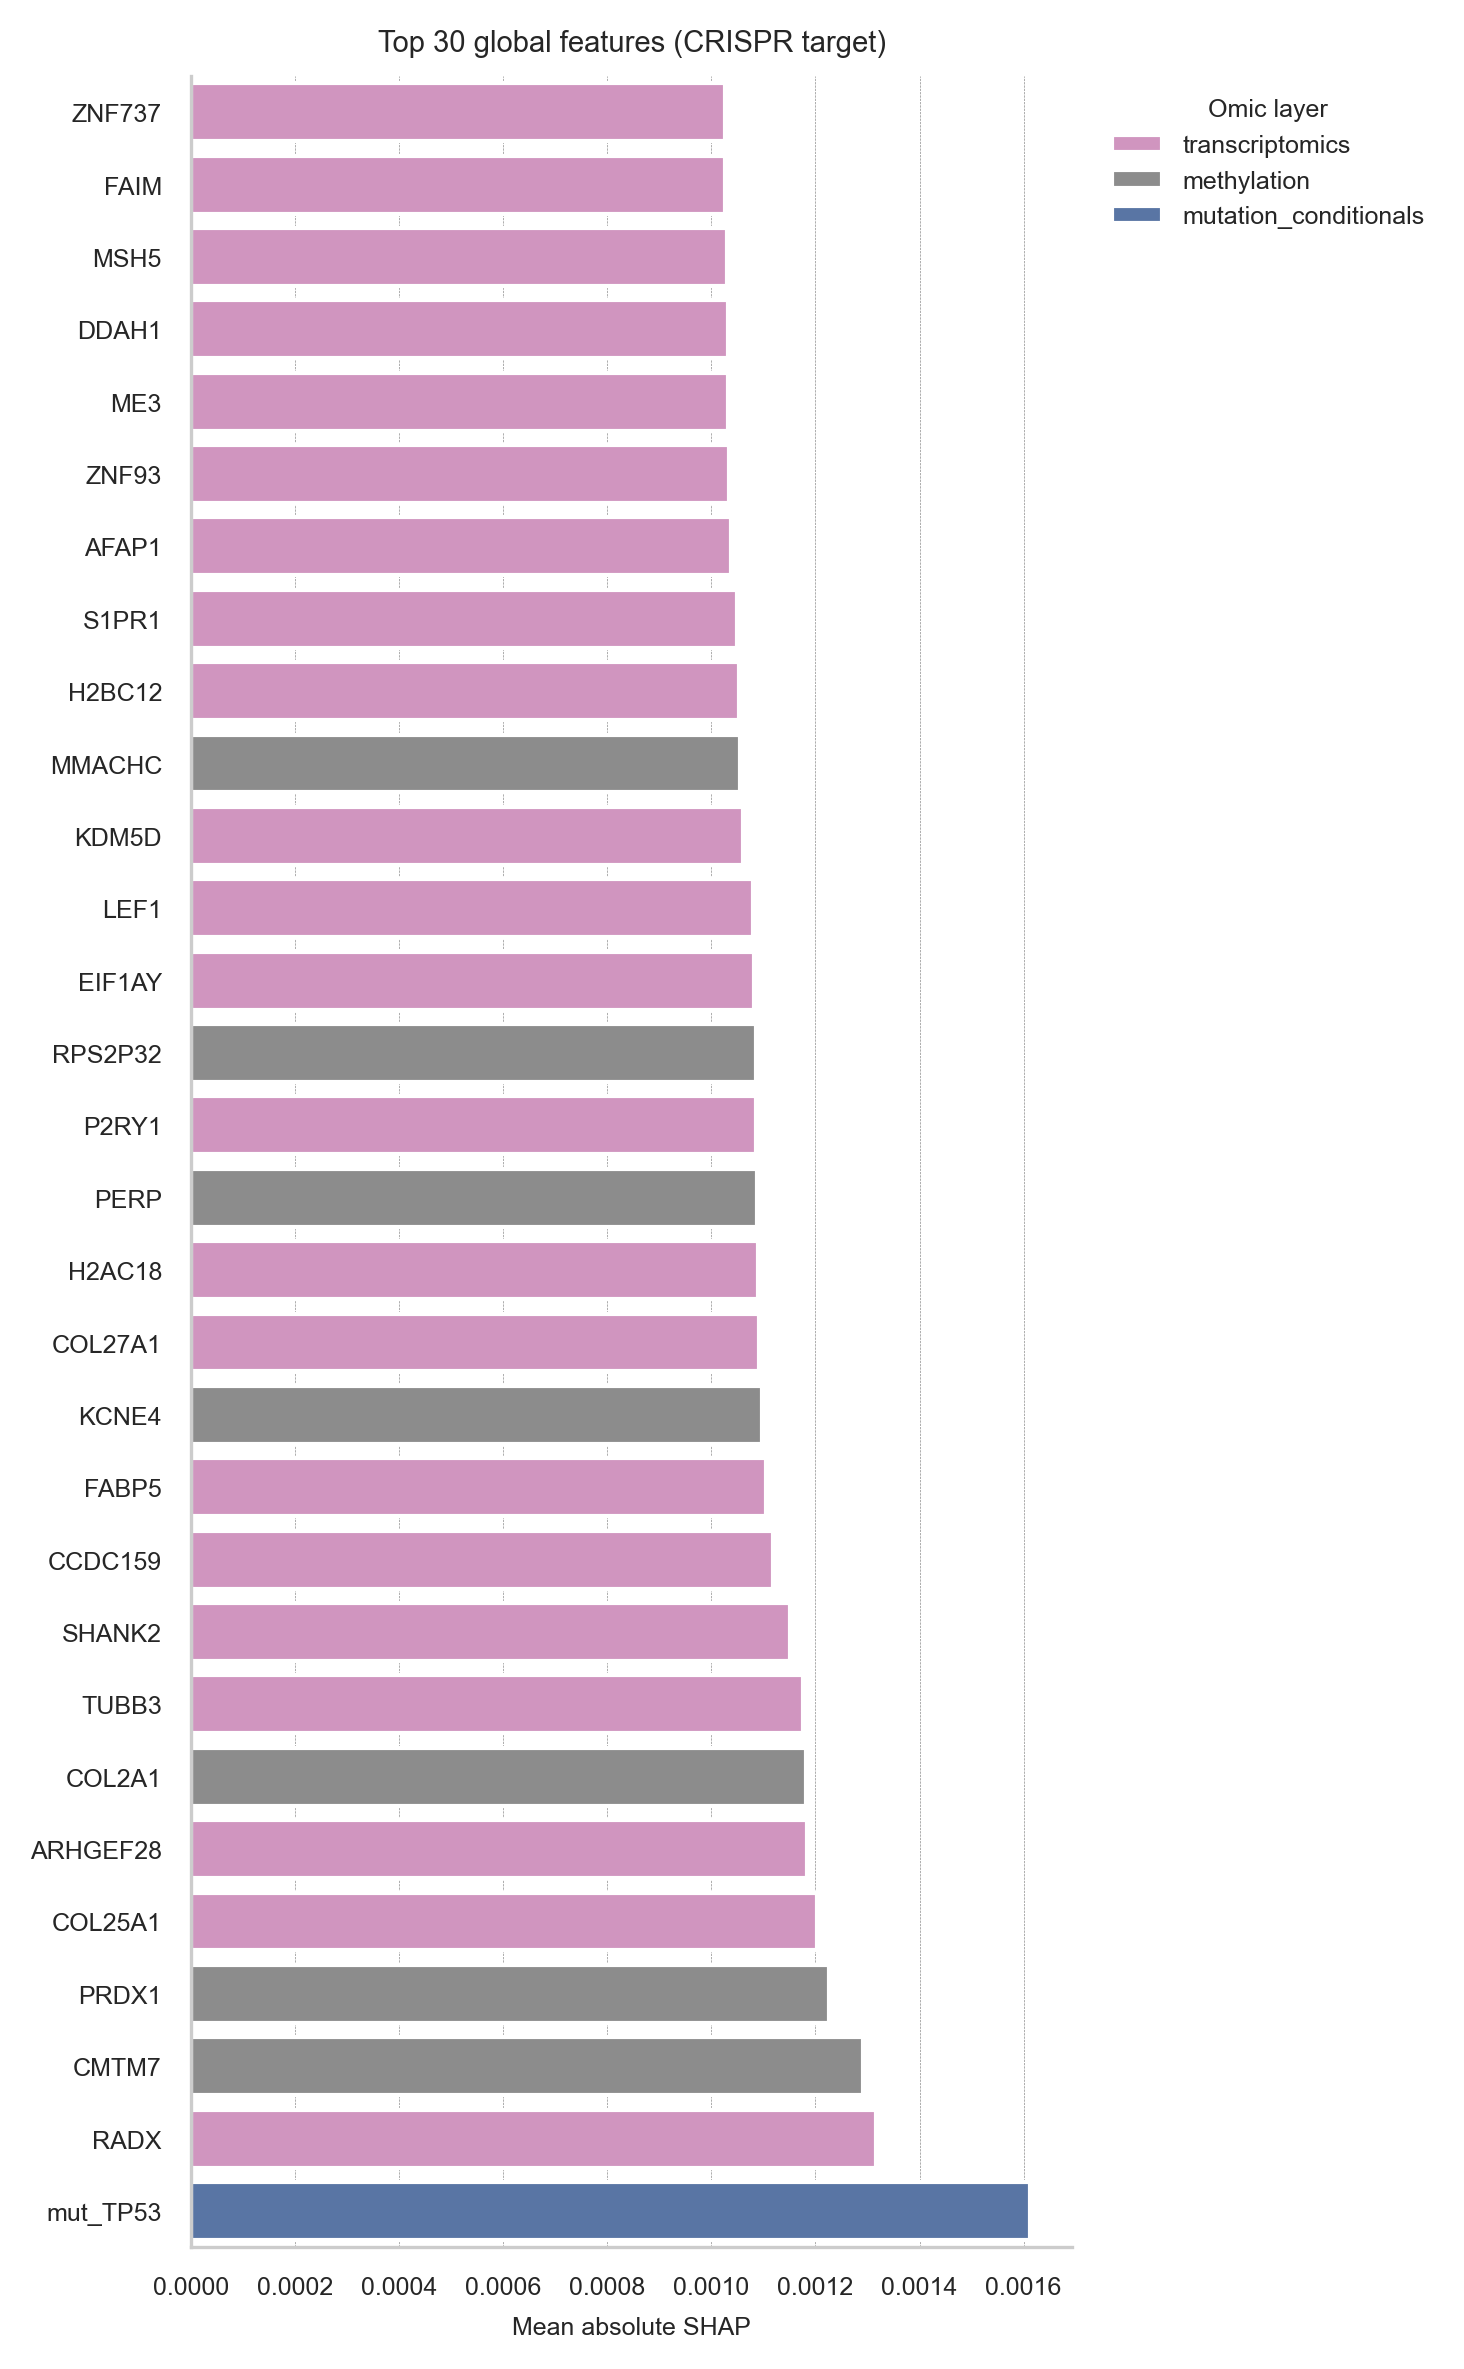

In [4]:
palette = dict(PhenPred.OMIC_PALETTE)
palette.setdefault("mutations", "#8c8c8c")
palette["mutation_conditionals"] = palette.get("conditionals", "#4c72b0")

omic_plot_df = omic_rank_df.copy()
omic_plot_df["omic_layer"] = omic_plot_df["omic_layer"].replace(
    {"conditionals": "mutation_conditionals"}
)
omic_plot_df = omic_plot_df.sort_values("importance", ascending=True)
omic_colors = [palette.get(v, "#8c8c8c") for v in omic_plot_df["omic_layer"]]

plt.figure(figsize=(5.2, 2.8))
plt.barh(omic_plot_df["omic_layer"], omic_plot_df["importance"], color=omic_colors)
plt.xlabel("Mean absolute SHAP")
plt.ylabel("")
plt.title("Global SHAP by omic data type")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{TIMESTAMP}_global_shap_by_omic_crispr.png")
plt.show()


top_n = 30
plot_df = feature_rank_df.copy()
plot_df["omic_layer"] = plot_df["omic_layer"].replace({"conditionals": "mutation_conditionals"})
plot_df["feature_name"] = plot_df["feature"].map(
    lambda x: x.split("_", 1)[1] if "_" in x else x
)
plot_df = plot_df.head(top_n).iloc[::-1]

plt.figure(figsize=(5, 8))
sns.barplot(
    data=plot_df,
    x="importance",
    y="feature_name",
    hue="omic_layer",
    dodge=False,
    palette=palette,
)
plt.xlabel("Mean absolute SHAP")
plt.ylabel("")
plt.title(f"Top {top_n} global features (CRISPR target)")
plt.legend(title="Omic layer", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / f"{TIMESTAMP}_top{top_n}_global_features_crispr.png")
plt.show()



## Target-level analysis for selected CRISPR genes

This section first tries `${TIMESTAMP}_shap_values_crisprcas9.csv.gz`
(the full SHAP matrix for the targets explained in that run).

If needed, it falls back to `${TIMESTAMP}_shap_values_top_features_crisprcas9.feather`.



In [9]:
target_df = None
if TOP_FEATURES_FEATHER.exists():
    try:
        target_df = pd.read_feather(TOP_FEATURES_FEATHER)
        target_df["abs_shap"] = target_df["Shap_value"].abs()
        target_df["omic_layer"] = target_df["omics_feature"].str.split("_").str[0]
        target_df["omic_layer"] = target_df["omic_layer"].replace(
            {"conditionals": "mutation_conditionals"}
        )
        print("Loaded top-feature SHAP feather:", target_df.shape)
        display(target_df.head())
    except Exception as exc:
        print(f"Could not read top-features feather ({type(exc).__name__}): {exc}")
else:
    print("Top-features feather not found. Re-run SHAP without --skip-top200.")



Loaded top-feature SHAP feather: (9990000, 6)


,Sample_ID,target_name,omics_feature,Shap_value,abs_shap,omic_layer
333,00986346fd340ceae8b317af4d97769a41d3d3507290d3...,SRSF7,transcriptomics_A2M,0.000995,0.000995,transcriptomics
334,010f04421c085f062f6ce4172ddd81a31bf70f105e9778...,SRSF7,transcriptomics_A2M,-0.001522,0.001522,transcriptomics
335,011846d75201a20ca12b069526d6a68fb5feab9294ffe9...,SRSF7,transcriptomics_A2M,0.000392,0.000392,transcriptomics
336,03b3b1841901b0650013701ad8ca0c78f8890523f08950...,SRSF7,transcriptomics_A2M,0.001368,0.001368,transcriptomics
337,03f0729165a7c226d2e36bee017da45d3f423516311bb3...,SRSF7,transcriptomics_A2M,0.000310,0.000310,transcriptomics


In [10]:
def summarize_top_features_long_df(long_df):
    if long_df is None or long_df.empty:
        return pd.DataFrame(
            columns=["target_name", "omics_feature", "omic_layer", "abs_shap", "feature_name"]
        )

    tmp = long_df.copy()
    if "abs_shap" not in tmp.columns:
        tmp["abs_shap"] = tmp["Shap_value"].abs()

    tmp["omic_layer"] = tmp["omics_feature"].str.split("_").str[0]
    tmp["omic_layer"] = tmp["omic_layer"].replace({"conditionals": "mutation_conditionals"})

    feat_summary = (
        tmp.groupby(["target_name", "omics_feature", "omic_layer"], as_index=False)["abs_shap"]
        .mean()
    )
    feat_summary["feature_name"] = feat_summary["omics_feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )
    return feat_summary


def load_requested_targets_from_full_shap(full_shap_csv, target_genes, chunk_size=64):
    if not full_shap_csv.exists():
        return None, []

    header_cols = pd.read_csv(full_shap_csv, nrows=0).columns.tolist()
    feature_cols = [c for c in header_cols if c not in {"target_name", "Sample ID"}]
    if len(feature_cols) == 0:
        return None, []

    target_genes = list(dict.fromkeys(target_genes))
    abs_sums = {g: pd.Series(0.0, index=feature_cols) for g in target_genes}
    counts = {g: 0 for g in target_genes}

    for chunk in pd.read_csv(full_shap_csv, chunksize=chunk_size):
        chunk = chunk[chunk["target_name"].isin(target_genes)]
        if chunk.empty:
            continue

        for g, gdf in chunk.groupby("target_name"):
            abs_sums[g] = abs_sums[g].add(gdf[feature_cols].abs().sum(axis=0), fill_value=0.0)
            counts[g] += len(gdf)

    present_targets = [g for g in target_genes if counts[g] > 0]
    if len(present_targets) == 0:
        return None, []

    summary_parts = []
    for g in present_targets:
        mean_abs = (abs_sums[g] / counts[g]).rename("abs_shap")
        tmp = mean_abs.reset_index().rename(columns={"index": "omics_feature"})
        tmp["target_name"] = g
        summary_parts.append(tmp)

    summary_df = pd.concat(summary_parts, ignore_index=True)
    summary_df["omic_layer"] = summary_df["omics_feature"].str.split("_").str[0]
    summary_df["omic_layer"] = summary_df["omic_layer"].replace(
        {"conditionals": "mutation_conditionals"}
    )
    summary_df["feature_name"] = summary_df["omics_feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )

    return summary_df, present_targets


def get_target_top_features(feature_summary_df, target_name, n=20):
    if feature_summary_df is None or feature_summary_df.empty:
        raise ValueError("No feature summary data available.")

    tmp = (
        feature_summary_df[feature_summary_df["target_name"] == target_name]
        .sort_values("abs_shap", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    if tmp.empty:
        raise ValueError(f"Target '{target_name}' not found.")

    return tmp


def build_top_feature_map(feature_summary_df, target_names, n=20):
    return {
        t: get_target_top_features(feature_summary_df, t, n=n)["omics_feature"].tolist()
        for t in target_names
    }


def load_target_swarm_points_from_full_shap(full_shap_csv, target_feature_map, chunk_size=64):
    if not full_shap_csv.exists() or not target_feature_map:
        return pd.DataFrame(
            columns=["target_name", "Sample ID", "omics_feature", "Shap_value", "omic_layer", "feature_name"]
        )

    selected_features = sorted({f for vals in target_feature_map.values() for f in vals})
    usecols = ["target_name", "Sample ID", *selected_features]
    parts = []

    for chunk in pd.read_csv(full_shap_csv, usecols=lambda c: c in usecols, chunksize=chunk_size):
        chunk = chunk[chunk["target_name"].isin(target_feature_map.keys())]
        if chunk.empty:
            continue

        for target_name, feats in target_feature_map.items():
            sub = chunk[chunk["target_name"] == target_name]
            if sub.empty:
                continue

            available_feats = [f for f in feats if f in sub.columns]
            if not available_feats:
                continue

            long_part = sub[["Sample ID", *available_feats]].melt(
                id_vars="Sample ID",
                var_name="omics_feature",
                value_name="Shap_value",
            )
            long_part["target_name"] = target_name
            parts.append(long_part)

    if not parts:
        return pd.DataFrame(
            columns=["target_name", "Sample ID", "omics_feature", "Shap_value", "omic_layer", "feature_name"]
        )

    swarm_df = pd.concat(parts, ignore_index=True)
    swarm_df["omic_layer"] = swarm_df["omics_feature"].str.split("_").str[0]
    swarm_df["omic_layer"] = swarm_df["omic_layer"].replace(
        {"conditionals": "mutation_conditionals"}
    )
    swarm_df["feature_name"] = swarm_df["omics_feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )
    return swarm_df


def _make_panel_axes(n_targets, ncols=3, panel_width=4.8, panel_height=5.8):
    ncols = max(1, min(ncols, n_targets))
    nrows = int(np.ceil(n_targets / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(panel_width * ncols + 1.2, panel_height * nrows),
        squeeze=False,
    )
    axes = axes.flatten()
    for ax in axes[n_targets:]:
        ax.axis("off")
    return fig, axes


def plot_target_top_features_subplots(feature_summary_df, target_names, n=20, ncols=3):
    fig, axes = _make_panel_axes(len(target_names), ncols=ncols)

    legend_handles, legend_labels = None, None

    for ax, target_name in zip(axes, target_names):
        feat_df = get_target_top_features(feature_summary_df, target_name, n=n).iloc[::-1]

        sns.barplot(
            data=feat_df,
            x="abs_shap",
            y="feature_name",
            hue="omic_layer",
            dodge=False,
            palette=palette,
            ax=ax,
        )
        ax.set_xlabel("Mean absolute SHAP")
        ax.set_ylabel("")
        ax.set_title(target_name)

        handles, labels = ax.get_legend_handles_labels()
        if legend_handles is None and len(handles) > 0:
            legend_handles, legend_labels = handles, labels
        if ax.legend_ is not None:
            ax.legend_.remove()

    right = 0.86 if legend_handles else 0.98
    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Omic layer",
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
        )

    fig.suptitle(f"Top {n} features explaining selected CRISPR targets")
    fig.tight_layout(rect=[0, 0, right, 0.96])
    return fig


def _downsample_swarm_points(tmp, max_points_per_feature):
    if max_points_per_feature is None:
        return tmp

    sampled_parts = []
    for _, group in tmp.groupby("omics_feature", sort=False):
        if len(group) <= max_points_per_feature:
            sampled_parts.append(group)
        else:
            sampled_parts.append(group.sample(max_points_per_feature, random_state=0))
    return pd.concat(sampled_parts, ignore_index=True) if sampled_parts else tmp


def plot_target_swarm_subplots(
    swarm_df,
    feature_summary_df,
    target_names,
    n=20,
    ncols=3,
    max_points_per_feature=200,
):
    if swarm_df is None or swarm_df.empty:
        print("No sample-level SHAP values available for swarm plots.")
        return None

    fig, axes = _make_panel_axes(len(target_names), ncols=ncols)
    legend_handles, legend_labels = None, None

    for ax, target_name in zip(axes, target_names):
        top_feats = get_target_top_features(feature_summary_df, target_name, n=n)
        order_df = top_feats.iloc[::-1]
        top_omics_features = set(top_feats["omics_feature"])
        feature_order = order_df["feature_name"].tolist()

        tmp = swarm_df[
            (swarm_df["target_name"] == target_name)
            & (swarm_df["omics_feature"].isin(top_omics_features))
        ].copy()

        if tmp.empty:
            ax.text(0.5, 0.5, "No swarm data available", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        if "feature_name" not in tmp.columns:
            tmp["feature_name"] = tmp["omics_feature"].map(
                lambda x: x.split("_", 1)[1] if "_" in x else x
            )
        if "omic_layer" not in tmp.columns:
            tmp["omic_layer"] = tmp["omics_feature"].str.split("_").str[0]
            tmp["omic_layer"] = tmp["omic_layer"].replace(
                {"conditionals": "mutation_conditionals"}
            )

        tmp = _downsample_swarm_points(tmp, max_points_per_feature=max_points_per_feature)
        tmp["feature_name"] = pd.Categorical(tmp["feature_name"], categories=feature_order, ordered=True)
        tmp = tmp.sort_values("feature_name")

        sns.swarmplot(
            data=tmp,
            x="Shap_value",
            y="feature_name",
            hue="omic_layer",
            palette=palette,
            size=2.2,
            alpha=0.75,
            linewidth=0,
            ax=ax,
        )
        ax.axvline(0.0, color="#666666", linestyle="--", linewidth=1)
        ax.set_xlabel("SHAP value")
        ax.set_ylabel("")
        ax.set_title(target_name)

        handles, labels = ax.get_legend_handles_labels()
        if legend_handles is None and len(handles) > 0:
            legend_handles, legend_labels = handles, labels
        if ax.legend_ is not None:
            ax.legend_.remove()

    right = 0.86 if legend_handles else 0.98
    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Omic layer",
            bbox_to_anchor=(1.02, 0.5),
            loc="center left",
        )

    fig.suptitle(f"Swarm SHAP distributions for top {n} features per target")
    fig.tight_layout(rect=[0, 0, right, 0.96])
    return fig




In [11]:
# Configure targets for target-level bar plots.
# Option A: set an explicit list here.
TARGET_GENE_LIST = ["MDM2", "MDM4", "PIK3CA"]

# Option B: leave TARGET_GENE_LIST empty to load from file.
TARGET_GENE_LIST_PATH = FILES_DIR / "shap_target_genes.txt"

TARGET_TOP_N = 20
TARGET_NCOLS = 3
MAX_TARGETS_PER_FIG = 9

if len(TARGET_GENE_LIST) == 0:
    if TARGET_GENE_LIST_PATH.exists():
        TARGET_GENE_LIST = [
            g.strip() for g in TARGET_GENE_LIST_PATH.read_text().splitlines() if g.strip()
        ]
        print(f"Loaded {len(TARGET_GENE_LIST)} targets from {TARGET_GENE_LIST_PATH}")
    else:
        raise ValueError(
            "TARGET_GENE_LIST is empty and shap_target_genes.txt was not found. "
            "Set TARGET_GENE_LIST manually."
        )

# Prefer full SHAP CSV (complete features). Fall back to top-features feather.
target_feature_summary, targets_found = load_requested_targets_from_full_shap(
    FULL_SHAP_CSV,
    TARGET_GENE_LIST,
    chunk_size=64,
)

if target_feature_summary is None or target_feature_summary.empty:
    print("Falling back to top-features feather summary.")
    target_feature_summary = summarize_top_features_long_df(target_df)
    found_set = set(target_feature_summary["target_name"].unique())
    targets_found = [g for g in TARGET_GENE_LIST if g in found_set]

if target_feature_summary is None or target_feature_summary.empty:
    raise ValueError("No target-level SHAP summary data is available for plotting.")

targets_requested = list(dict.fromkeys(TARGET_GENE_LIST))
targets_found = [g for g in targets_requested if g in set(targets_found)]
missing_targets = [g for g in targets_requested if g not in set(targets_found)]

print(f"Targets requested: {len(targets_requested)}")
print(f"Targets found: {len(targets_found)}")
if missing_targets:
    miss_preview = ", ".join(missing_targets[:20])
    if len(missing_targets) > 20:
        miss_preview += ", ..."
    print(f"Targets missing from SHAP outputs: {miss_preview}")

preview_df = (
    target_feature_summary[target_feature_summary["target_name"].isin(targets_found)]
    .sort_values(["target_name", "abs_shap"], ascending=[True, False])
    .groupby("target_name", as_index=False)
    .head(5)
)
display(preview_df)



Falling back to top-features feather summary.
Targets requested: 3
Targets found: 0
Targets missing from SHAP outputs: MDM2, MDM4, PIK3CA


,target_name,omics_feature,omic_layer,abs_shap,feature_name


In [12]:
targets_to_plot = [g for g in TARGET_GENE_LIST if g in set(targets_found)]
if len(targets_to_plot) == 0:
    raise ValueError("No requested targets were found in the available SHAP outputs.")

saved_paths = []
for page_idx, start in enumerate(range(0, len(targets_to_plot), MAX_TARGETS_PER_FIG), start=1):
    page_targets = targets_to_plot[start : start + MAX_TARGETS_PER_FIG]
    fig = plot_target_top_features_subplots(
        target_feature_summary,
        target_names=page_targets,
        n=TARGET_TOP_N,
        ncols=min(TARGET_NCOLS, len(page_targets)),
    )

    if fig._suptitle is not None:
        fig._suptitle.set_text(
            f"Top {TARGET_TOP_N} features per selected CRISPR target"
        )

    page_suffix = (
        f"page{page_idx:02d}"
        if len(targets_to_plot) > MAX_TARGETS_PER_FIG
        else "all"
    )
    out_path = OUT_DIR / f"{TIMESTAMP}_target_list_top{TARGET_TOP_N}_barplots_{page_suffix}.png"
    fig.savefig(out_path, dpi=220)
    saved_paths.append(out_path)
    plt.show()

print("Saved target bar plots:")
for p in saved_paths:
    print(" -", p)



ValueError: No requested targets were found in the available SHAP outputs.

## Addendum: Mean-Abs SHAP Outputs and Target Query

This section is appended and does not modify earlier cells. It loads the new `*_mean_abs` SHAP files and provides a helper to query a list of CRISPR target genes.


In [5]:
# New aggregated SHAP outputs (mean absolute SHAP only)
FEATURE_RANK_CSV_MEAN_ABS = FILES_DIR / f"{TIMESTAMP}_shap_feature_ranking_crisprcas9_mean_abs.csv"
OMIC_RANK_CSV_MEAN_ABS = FILES_DIR / f"{TIMESTAMP}_shap_omic_ranking_crisprcas9_mean_abs.csv"
TOP_FEATURES_FEATHER_MEAN_ABS = FILES_DIR / f"{TIMESTAMP}_shap_values_top_features_crisprcas9_mean_abs.feather"
FULL_SHAP_CSV_MEAN_ABS = FILES_DIR / f"{TIMESTAMP}_shap_values_crisprcas9_mean_abs.csv.gz"

def load_ccma_crispr_mean_abs_outputs():
    # Ranking tables
    feat_path = FEATURE_RANK_CSV_MEAN_ABS if FEATURE_RANK_CSV_MEAN_ABS.exists() else FEATURE_RANK_CSV
    omic_path = OMIC_RANK_CSV_MEAN_ABS if OMIC_RANK_CSV_MEAN_ABS.exists() else OMIC_RANK_CSV
    feature_rank = pd.read_csv(feat_path) if feat_path.exists() else pd.DataFrame()
    omic_rank = pd.read_csv(omic_path) if omic_path.exists() else pd.DataFrame()

    # Full target-level table (preferred: mean_abs wide table with one row per target)
    target_matrix = None
    if FULL_SHAP_CSV_MEAN_ABS.exists():
        target_matrix = pd.read_csv(FULL_SHAP_CSV_MEAN_ABS)
    elif FULL_SHAP_CSV.exists():
        target_matrix = pd.read_csv(FULL_SHAP_CSV)

    # Top-feature table (optional fallback)
    top_path = TOP_FEATURES_FEATHER_MEAN_ABS if TOP_FEATURES_FEATHER_MEAN_ABS.exists() else TOP_FEATURES_FEATHER
    top_long = pd.read_feather(top_path) if top_path.exists() else pd.DataFrame()

    if not top_long.empty:
        if "mean_abs_shap" not in top_long.columns:
            if "Shap_value" in top_long.columns:
                top_long["mean_abs_shap"] = top_long["Shap_value"].abs()
            elif "avg_abs_Shap_value" in top_long.columns:
                top_long["mean_abs_shap"] = top_long["avg_abs_Shap_value"].astype(float)
        if "omic_layer" not in top_long.columns and "omics_feature" in top_long.columns:
            top_long["omic_layer"] = top_long["omics_feature"].str.split("_").str[0]
        if "omic_layer" in top_long.columns:
            top_long["omic_layer"] = top_long["omic_layer"].replace({"conditionals": "mutation_conditionals"})
        if "feature_name" not in top_long.columns and "omics_feature" in top_long.columns:
            top_long["feature_name"] = top_long["omics_feature"].map(
                lambda x: x.split("_", 1)[1] if "_" in x else x
            )

    print(f"Feature ranking file: {feat_path}")
    print(f"Omic ranking file: {omic_path}")
    print(f"Top-features file: {top_path if top_path.exists() else 'not found'}")
    print(
        "Full target SHAP file:",
        FULL_SHAP_CSV_MEAN_ABS
        if FULL_SHAP_CSV_MEAN_ABS.exists()
        else (FULL_SHAP_CSV if FULL_SHAP_CSV.exists() else "not found"),
    )

    return feature_rank, omic_rank, target_matrix, top_long


feature_rank_mean_abs_df, omic_rank_mean_abs_df, target_matrix_df, top_long_df = load_ccma_crispr_mean_abs_outputs()

display(feature_rank_mean_abs_df.head())
display(omic_rank_mean_abs_df.head())

if target_matrix_df is not None and not target_matrix_df.empty and "target_name" in target_matrix_df.columns:
    print("Targets available in full target matrix:", target_matrix_df["target_name"].nunique())
else:
    print("No full target matrix found for this timestamp.")


Feature ranking file: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_feature_ranking_crisprcas9_mean_abs.csv
Omic ranking file: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_omic_ranking_crisprcas9_mean_abs.csv
Top-features file: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_values_top_features_crisprcas9_mean_abs.feather
Full target SHAP file: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/20260226_031500_shap_values_crisprcas9_mean_abs.csv.gz


,feature,importance,omic_layer
0,conditionals_mut_TP53,0.002141,conditionals
1,conditionals_mut_TERT,0.000822,conditionals
2,methylation_CMTM7,0.000728,methylation
3,conditionals_mut_H3_3A_p_K28M,0.000724,conditionals
4,methylation_PRDX1,0.000691,methylation


,omic_layer,importance
0,transcriptomics,0.000219
1,methylation,0.000189
2,conditionals,0.000019


Targets available in full target matrix: 966


In [6]:
def query_target_genes_mean_abs(target_genes, top_n=20):
    target_genes = [str(g).strip() for g in target_genes if str(g).strip()]
    target_genes = list(dict.fromkeys(target_genes))
    if len(target_genes) == 0:
        return (
            pd.DataFrame(
                columns=[
                    "target_name",
                    "omics_feature",
                    "feature_name",
                    "omic_layer",
                    "mean_abs_shap",
                ]
            ),
            [],
        )

    out_parts = []
    missing = []

    # Preferred source: full mean_abs matrix (target_name + feature columns).
    if target_matrix_df is not None and not target_matrix_df.empty and "target_name" in target_matrix_df.columns:
        mat = target_matrix_df.copy()
        feature_cols = [c for c in mat.columns if c not in {"target_name", "Sample ID"}]

        for g in target_genes:
            gdf = mat[mat["target_name"] == g]
            if gdf.empty:
                missing.append(g)
                continue

            # Robust to accidental duplicate target rows.
            vec = gdf[feature_cols].apply(pd.to_numeric, errors="coerce").mean(axis=0)
            vec = vec.dropna().sort_values(ascending=False).head(top_n)

            tmp = vec.reset_index()
            tmp.columns = ["omics_feature", "mean_abs_shap"]
            tmp.insert(0, "target_name", g)
            out_parts.append(tmp)

    # Fallback source: top-features long table.
    elif top_long_df is not None and not top_long_df.empty:
        long_df = top_long_df.copy()
        if "mean_abs_shap" not in long_df.columns and "Shap_value" in long_df.columns:
            long_df["mean_abs_shap"] = long_df["Shap_value"].abs()

        for g in target_genes:
            gdf = long_df[long_df["target_name"] == g]
            if gdf.empty:
                missing.append(g)
                continue

            tmp = (
                gdf.groupby("omics_feature", as_index=False)["mean_abs_shap"]
                .mean()
                .sort_values("mean_abs_shap", ascending=False)
                .head(top_n)
            )
            tmp.insert(0, "target_name", g)
            out_parts.append(tmp)
    else:
        missing = target_genes

    if len(out_parts) == 0:
        return (
            pd.DataFrame(
                columns=[
                    "target_name",
                    "omics_feature",
                    "feature_name",
                    "omic_layer",
                    "mean_abs_shap",
                ]
            ),
            missing,
        )

    out = pd.concat(out_parts, axis=0, ignore_index=True)
    out["omic_layer"] = out["omics_feature"].str.split("_").str[0]
    out["omic_layer"] = out["omic_layer"].replace({"conditionals": "mutation_conditionals"})
    out["feature_name"] = out["omics_feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )
    out = out.sort_values(["target_name", "mean_abs_shap"], ascending=[True, False]).reset_index(drop=True)
    return out, missing


# Set your target query here
QUERY_TARGET_GENES = ["MDM2", "MDM4", "PIK3CA"]
QUERY_TOP_N = 20

QUERY_TARGET_GENE_LIST_PATH = (
    TARGET_GENE_LIST_PATH
    if "TARGET_GENE_LIST_PATH" in globals()
    else FILES_DIR / "shap_target_genes.txt"
)
if len(QUERY_TARGET_GENES) == 0 and QUERY_TARGET_GENE_LIST_PATH.exists():
    QUERY_TARGET_GENES = [
        g.strip() for g in QUERY_TARGET_GENE_LIST_PATH.read_text().splitlines() if g.strip()
    ]

query_df, missing_genes = query_target_genes_mean_abs(QUERY_TARGET_GENES, top_n=QUERY_TOP_N)

print(f"Requested genes: {len(QUERY_TARGET_GENES)}")
print(f"Genes with SHAP results: {query_df['target_name'].nunique() if not query_df.empty else 0}")
if missing_genes:
    miss_preview = ", ".join(missing_genes[:20])
    if len(missing_genes) > 20:
        miss_preview += ", ..."
    print(f"Missing genes: {miss_preview}")

display(query_df.head(200))


Requested genes: 3
Genes with SHAP results: 3


,target_name,omics_feature,mean_abs_shap,omic_layer,feature_name
0,MDM2,conditionals_mut_TP53,0.013039,mutation_conditionals,mut_TP53
1,MDM2,conditionals_mut_TERT,0.002053,mutation_conditionals,mut_TERT
2,MDM2,methylation_FRG1,0.001369,methylation,FRG1
3,MDM2,methylation_UQCRH,0.001317,methylation,UQCRH
4,MDM2,transcriptomics_CLSPN,0.001285,transcriptomics,CLSPN
5,MDM2,methylation_NPEPPS,0.001267,methylation,NPEPPS
6,MDM2,transcriptomics_MCM5,0.001245,transcriptomics,MCM5
7,MDM2,methylation_PTMS,0.001229,methylation,PTMS
8,MDM2,methylation_PAFAH1B3,0.001193,methylation,PAFAH1B3
9,MDM2,transcriptomics_ORC1,0.001183,transcriptomics,ORC1


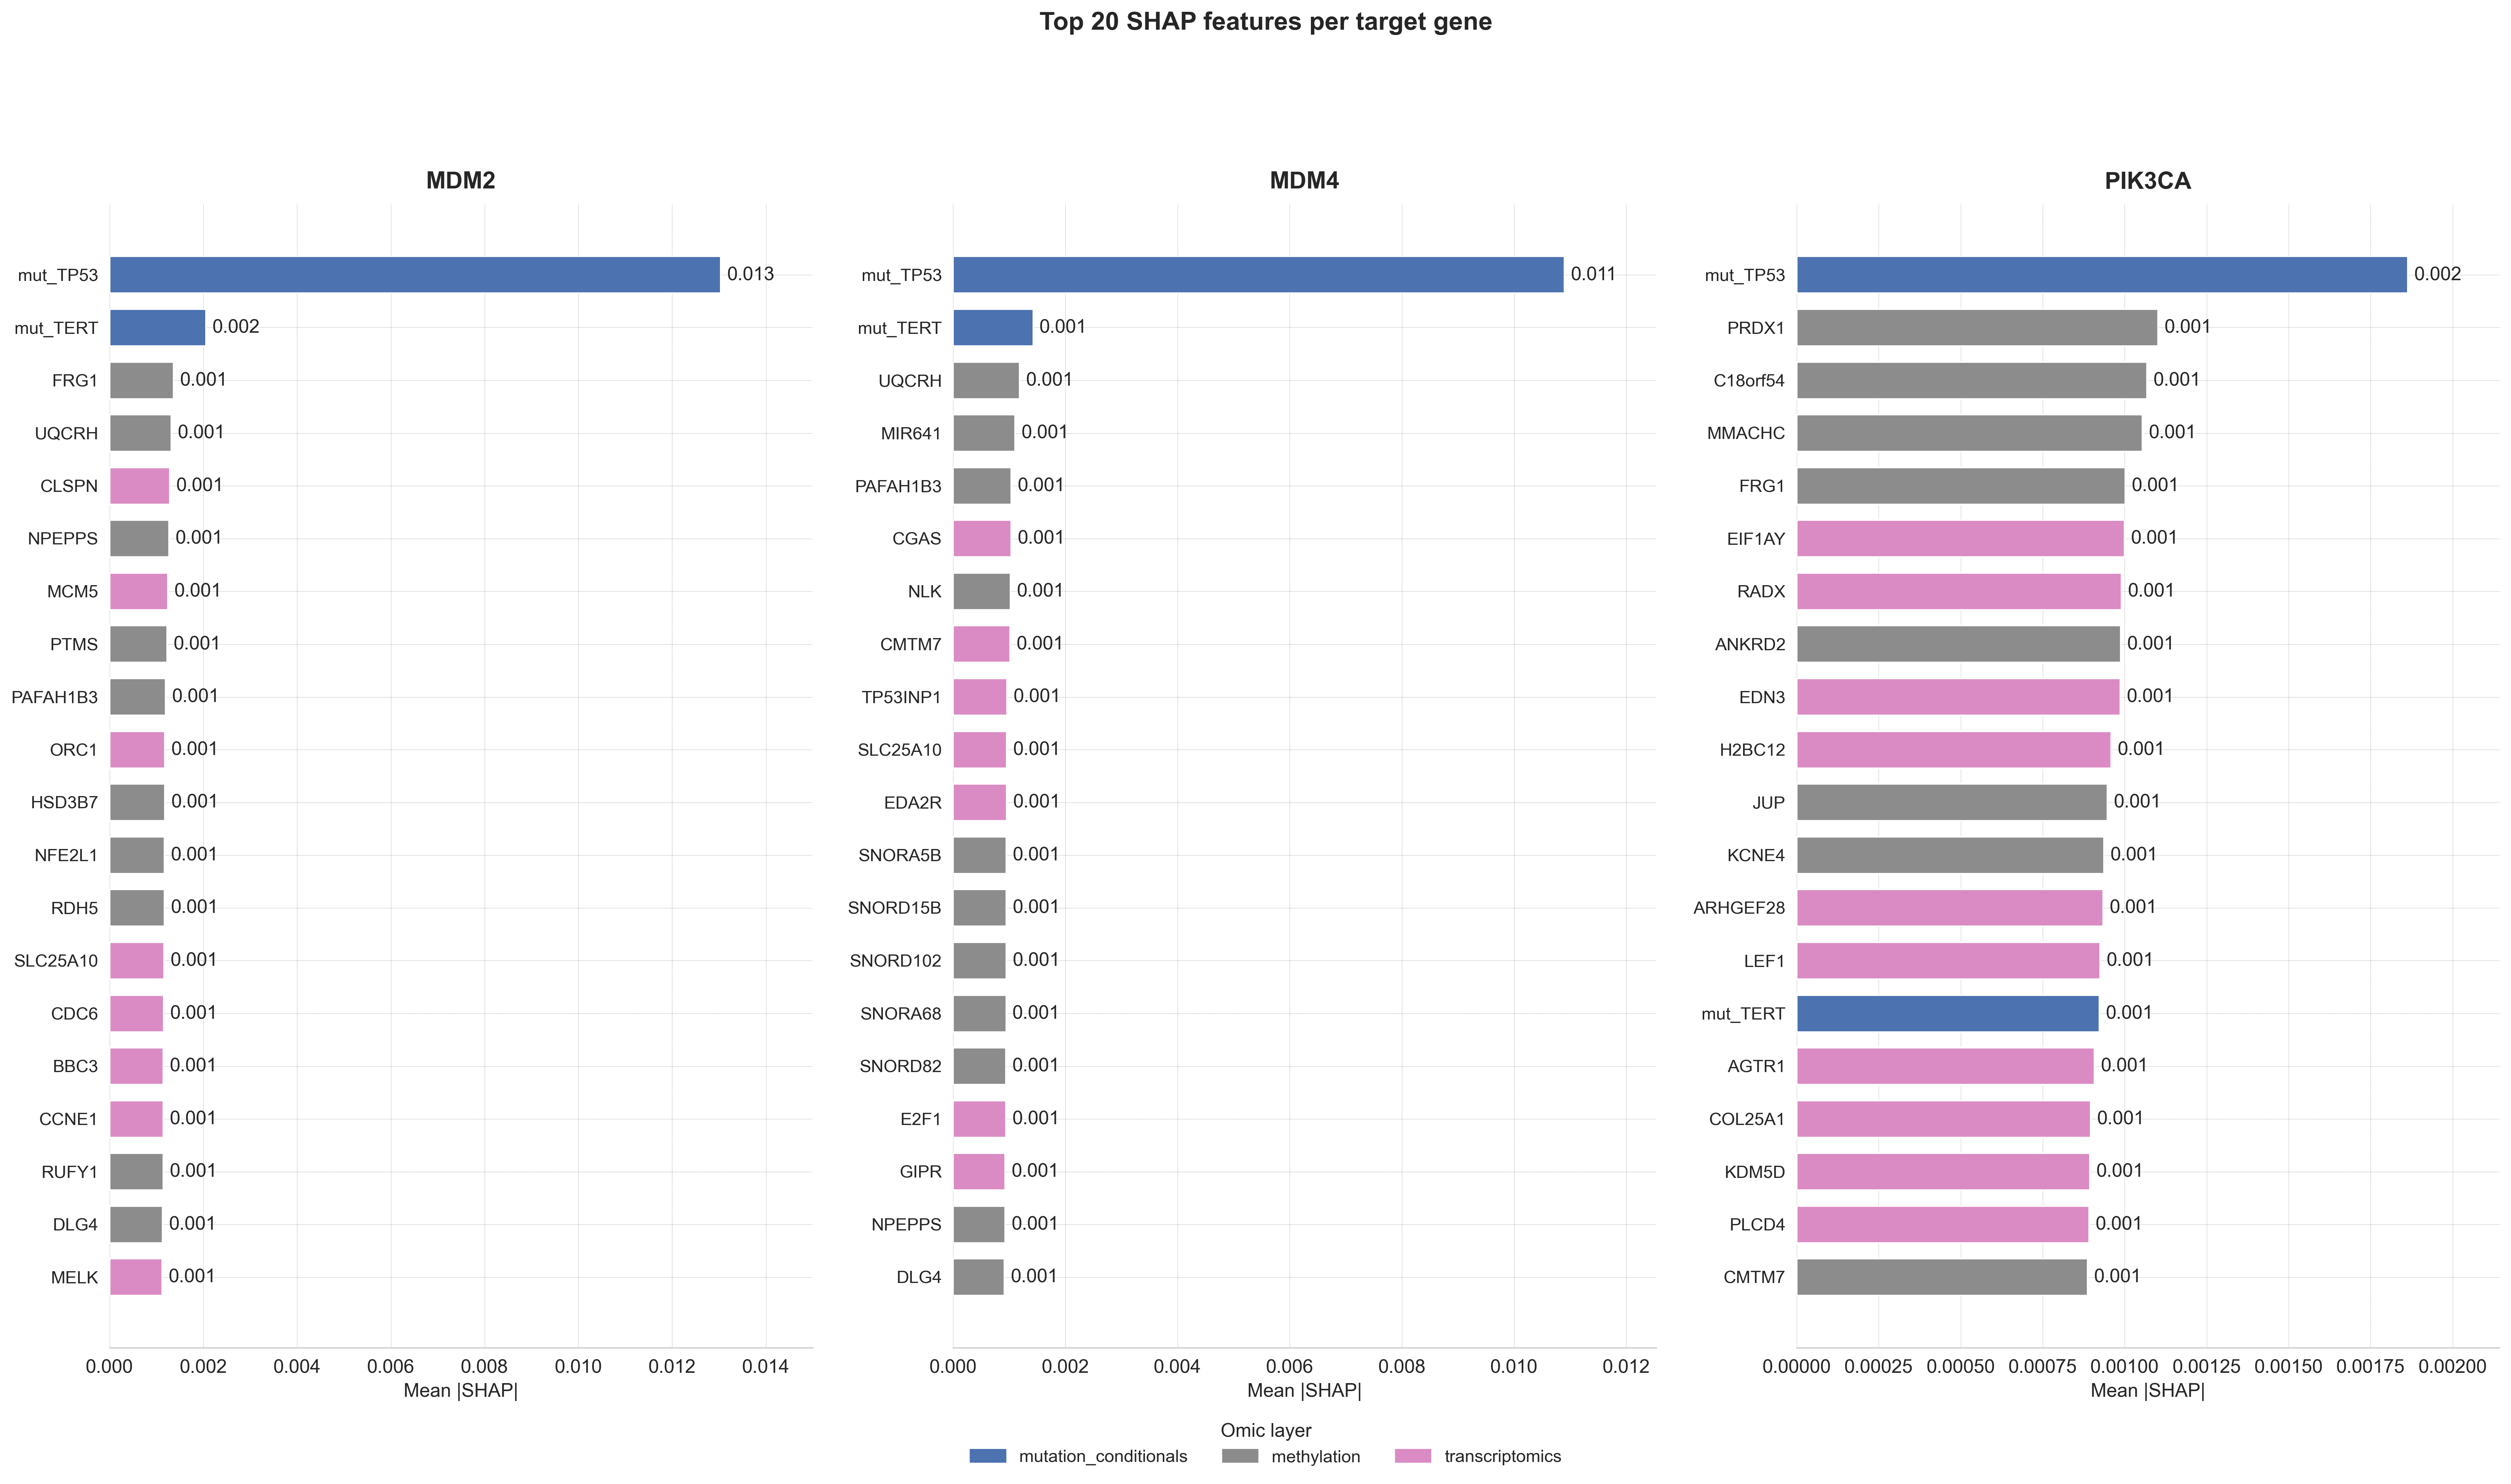

In [13]:
if not query_df.empty:
    genes = query_df["target_name"].unique().tolist()
    n_genes = len(genes)

    n_cols = min(3, n_genes)
    n_rows = int(np.ceil(n_genes / n_cols))

    # Taller rows and wider columns for readability
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(9 * n_cols, 0.55 * QUERY_TOP_N * n_rows + 2),
        squeeze=False,
    )

    for ax_idx, gene in enumerate(genes):
        row, col = divmod(ax_idx, n_cols)
        ax = axes[row][col]

        gdf = (
            query_df[query_df["target_name"] == gene]
            .sort_values("mean_abs_shap", ascending=True)
            .tail(QUERY_TOP_N)
        )

        bar_colors = [palette.get(layer, "#8c8c8c") for layer in gdf["omic_layer"]]
        bars = ax.barh(gdf["feature_name"], gdf["mean_abs_shap"], color=bar_colors, height=0.7)

        # Value labels at the end of each bar
        for bar in bars:
            w = bar.get_width()
            ax.text(
                w + ax.get_xlim()[1] * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{w:.3f}",
                va="center",
                ha="left",
                fontsize=12,
            )

        ax.set_title(gene, fontsize=15, fontweight="bold", pad=10)
        ax.set_xlabel("Mean |SHAP|", fontsize=12)
        ax.tick_params(axis="y", labelsize=11)
        ax.tick_params(axis="x", labelsize=12)
        ax.margins(x=0.15)
        sns.despine(ax=ax, left=True)

    # Hide unused axes
    for ax_idx in range(n_genes, n_rows * n_cols):
        row, col = divmod(ax_idx, n_cols)
        axes[row][col].set_visible(False)

    # Shared legend for omic layers
    seen_layers = query_df["omic_layer"].unique()
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=palette.get(layer, "#8c8c8c"), label=layer)
        for layer in seen_layers
    ]
    fig.legend(
        handles=legend_handles,
        title="Omic layer",
        title_fontsize=12,
        loc="lower center",
        ncol=min(len(seen_layers), 5),
        bbox_to_anchor=(0.5, 0.02),
        frameon=False,
        fontsize=11,
    )

    fig.suptitle(
        f"Top {QUERY_TOP_N} SHAP features per target gene",
        fontsize=16,
        fontweight="bold",
        y=1.01,
    )
    # plt.tight_layout(h_pad=3, w_pad=3)
    plt.savefig(OUT_DIR / f"{TIMESTAMP}_top_features_per_gene.pdf", bbox_inches="tight")
    plt.savefig(OUT_DIR / f"{TIMESTAMP}_top_features_per_gene.png", bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("query_df is empty – nothing to plot.")
